In [3]:
import torch
import numpy as np
from face_score import FACEScorer
import matplotlib.pyplot as plt

In [4]:
!head -n 1 sample/sample_nll_bbc_gemma2-2b_llama3-8b.txt 

7.5051 7.3118 7.1159 2.1035 0.0159 4.8266 4.3345 0.0215 0.6348 1.1885 6.7774 0.1070 8.8863 2.2863 10.2167 5.2771 1.2012 0.0481 4.1000 3.0367 0.5649 1.4841 0.8668 4.3982 10.6493 0.1445 0.0006 1.0179 2.9261 10.6887 0.0322 5.4501 5.5667 4.1768 0.0184 3.2616 0.5396 0.0003 3.0668 1.8177 3.1110 0.1696 0.0807 1.2073 4.6918 0.0176 0.0064 0.4497 2.5742 0.9454 0.0433 1.5455 0.1112 0.0094 0.7830 0.0607 0.1517 0.0792 0.9286 2.6546 0.0199 0.0006 0.3012 0.0957 0.1168 0.0004 0.0913 3.0693 2.6106 1.0832 2.6364 1.2647 0.3776 0.0002 3.3797 0.0685 15.0889 0.0090 1.7088 0.4934 2.3893 2.4811 3.2580 1.2288 5.8720 1.3482 3.6309 0.0130 0.0008 0.4908 0.2745 0.7514 17.7250 1.3395 0.0003 5.4989 0.4637 1.1482 1.3786 3.5904 0.6511 2.5342 4.1149 1.0110 2.3251 0.6781 0.1269 1.1393 0.1472 0.0738 0.4383 1.4326 5.4174 0.3187 1.6470 0.2783 1.3430 3.5736 2.7710 0.0051 1.2775 2.6715 0.1475 3.7812 3.2833 0.6331 1.0299 2.8317 4.1126 2.9407 0.0052 0.2154 0.5468 0.0647 4.1591 1.4627 0.3418 2.5564 6.0645 4.7677 2.2640 0.4926 1

In [6]:
face_scorer = FACEScorer(model_path='/Users/xy/models/gpt2-xl',
                         device='mps')

face_scorer.fft_processor.print_fft_args()

FFTProcessor: method=fft, preprocess=none, value=norm, require_sid=True


/Users/xy/.pyenv/versions/miniconda3-latest/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [4]:
nll_file = 'sample/sample_nll_bbc_gemma2-2b_llama3-8b.txt'
n_lines = 1
nlls = []
with open(nll_file, 'r') as f:
    for i, line in enumerate(f):
        if i == n_lines:
            break
        nll = np.array(line.split(), dtype=np.float32)
        nlls.append(nll)
print(nlls)

[array([7.5051e+00, 7.3118e+00, 7.1159e+00, ..., 4.6000e-03, 9.7000e-03,
       3.0000e-03], dtype=float32)]


In [7]:
x = nlls[0]
X = face_scorer.nll_to_spectrum([x])
print(X[0][0][:10], X[1][0][:10])

[1553.4221    304.32278   176.98238   255.38657    86.695274   17.096107
   63.884712   46.464798   91.16841    75.62485 ] [0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009]


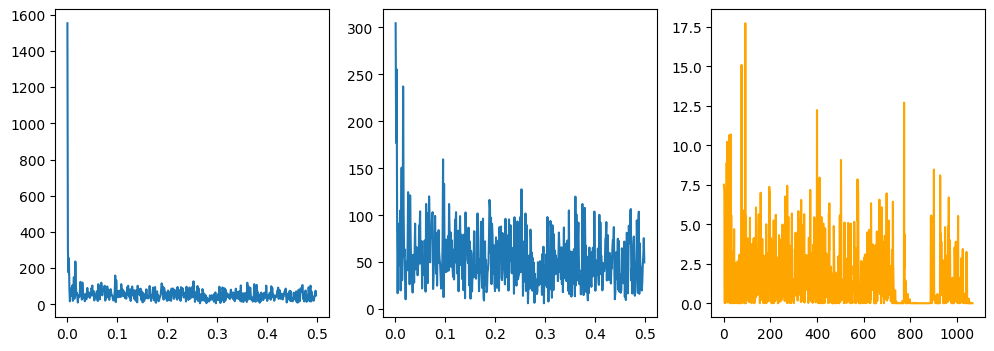

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(12,4))

ax[0].plot(X[1][0][:], X[0][0][:])
ax[1].plot(X[1][0][1:], X[0][0][1:])
ax[2].plot(np.arange(len(x)), x, color='orange')

### Auto Correlation analysis

In [8]:
def circular_autocorr(x, y):
    """Circular correlation of x and y"""
    if isinstance(x, np.ndarray):
        x = x.tolist()
    if isinstance(y, np.ndarray):
        y = y.tolist()
    ac = []
    for i in range(len(x)):
        ac.append(np.dot(x, y[i:] + y[:i]))
    return ac

In [10]:
x_acf = np.correlate(x, x, mode='same')
print(x_acf.shape, x.shape)

(1069,) (1069,)


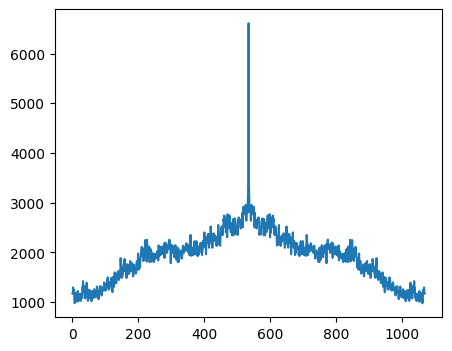

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(5,4))
ax.plot(x_acf)

In [12]:
# Basics of autocorrelation
x = [1, 2, 3]

x_acf = np.correlate(x, x, mode='valid')
print(f'valid x_acf: {x_acf}')
# [1,2,3] [1,2,3] -> 14

x_acf = np.correlate(x, x, mode='same')
print(f'same x_acf: {x_acf}')
# [1,2,3] dot [2,3,0] -> 8
# [1,2,3] dot [1,2,3] -> 14
# [1,2,3] dot [0,1,2] -> 8

x_acf = np.correlate(x, x, mode='full')
print(f'full x_acf: {x_acf}')
# [1,2,3] [3,0,0] -> 3

# np.correlate by default pad with zeros

# circular correlate
x0 = np.dot(x, x)
print(f'x0 = {x0}')

x1 = np.dot(x, x[1:] + x[:1])
print(f'x1 = {x1}')
# [1,2,3] [2,3,1] -> 11

x2 = np.dot(x, x[2:] + x[:2])
print(f'x2 = {x2}')
# [1,2,3] [3,1,2] -> 11

x_ac = circular_autocorr(x, x)
print(f'x_ac = {x_ac}')


valid x_acf: [14]
same x_acf: [ 8 14  8]
full x_acf: [ 3  8 14  8  3]
x0 = 14
x1 = 11
x2 = 11
x_ac = [14, 11, 11]


#### Sine examples

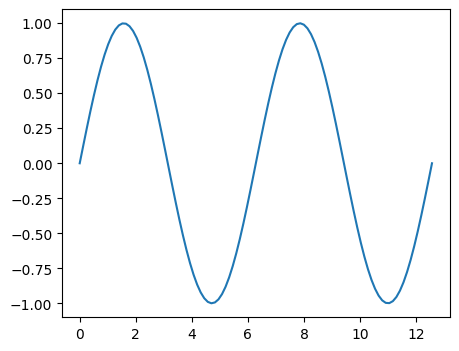

In [19]:
x = np.linspace(0, 4*np.pi, 100)
sin_x = np.sin(x)

fig, ax = plt.subplots(1, 1, figsize=(5,4))
ax.plot(x, sin_x)

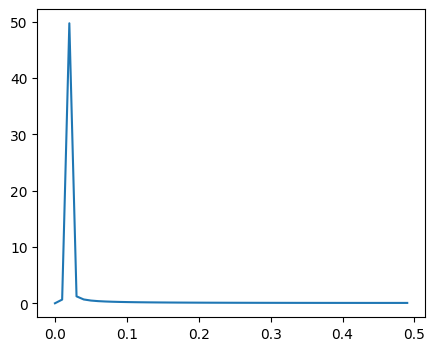

In [20]:
x_fft = face_scorer.fft_processor.process([sin_x])
# print(x_fft)

fig, ax = plt.subplots(1, 1, figsize=(5,4))
ax.plot(x_fft['freq'], x_fft['power'])


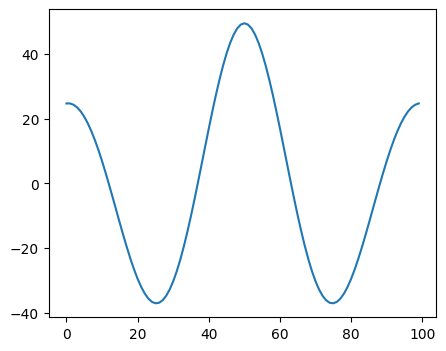

In [21]:
sin_x_acf = np.correlate(sin_x, sin_x, mode='same')
# print(f'sin_x_acf = {sin_x_acf}')

fig, ax = plt.subplots(1, 1, figsize=(5,4))
ax.plot(sin_x_acf)